# Week-4 Assignment: CIFAR-10 Image Classification (ANN vs CNN)
Student: Krishna Singh  
Program: Data Science Internship at Celebal Technologies

## Learning Objective
Build ANN and CNN on CIFAR-10 dataset and clearly explain why CNN performs better.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [11]:
# Load Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


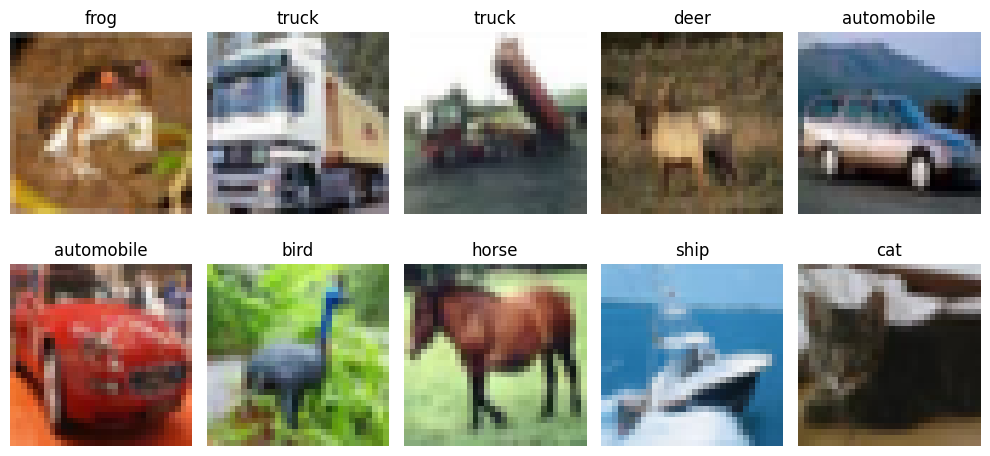

In [12]:
# Visualize Sample Images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Preprocessing
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## Part 1: ANN Model
ANN flattens the image and loses spatial information. This is why it performs poorly on images.

In [14]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_history = ann_model.fit(x_train_flat, y_train, 
                            epochs=20, 
                            validation_split=0.1, 
                            batch_size=64)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.2954 - loss: 1.9534 - val_accuracy: 0.2250 - val_loss: 2.1070
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.3396 - loss: 1.8283 - val_accuracy: 0.3354 - val_loss: 1.8309
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3533 - loss: 1.7913 - val_accuracy: 0.3838 - val_loss: 1.7530
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3633 - loss: 1.7626 - val_accuracy: 0.3832 - val_loss: 1.7441
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3739 - loss: 1.7434 - val_accuracy: 0.4128 - val_loss: 1.7043
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3824 - loss: 1.7204 - val_accuracy: 0.4020 - val_loss: 1.7004
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3842 - loss: 1.7078 - val_accuracy: 0.3970 - val_loss: 1.6826
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3946 - loss: 1.6858 - 

## Part 2: CNN Model
CNN uses convolution layers to detect edges, textures and objects. This is why it is much better for images.

In [15]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_history = cnn_model.fit(x_train_norm, y_train, 
                            epochs=25, 
                            validation_split=0.1, 
                            batch_size=64)

c:\Users\krish\OneDrive\Desktop\Data_Science_Internship_at_Celebal\CEI-DS-week4-assignment-Krishna-Singh-PCE\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step - accuracy: 0.3962 - loss: 1.6852 - val_accuracy: 0.5640 - val_loss: 1.2103
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 69ms/step - accuracy: 0.5341 - loss: 1.2963 - val_accuracy: 0.5828 - val_loss: 1.1879
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.6112 - loss: 1.1030 - val_accuracy: 0.6082 - val_loss: 1.1415
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.6612 - loss: 0.9672 - val_accuracy: 0.6536 - val_loss: 0.9995
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.6983 - loss: 0.8640 - val_accuracy: 0.6818 - val_loss: 0.9414
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 67ms/step - accuracy: 0.7287 - loss: 0.7845 - val_accuracy: 0.7178 - val_loss: 0.8485
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7526 - loss: 0.7166 - val_accuracy: 0.6564 - val_loss: 1.0382
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7740 - loss: 0.6502 - 

In [16]:
# Data Augmentation (Strong Training Strategy)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1)
])

print("Data Augmentation layers added - helps model generalize better")

Data Augmentation layers added - helps model generalize better


## Final Comparison

In [17]:
ann_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test)

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_acc, cnn_acc],
    "Test Loss": [ann_loss, cnn_loss]
})
comparison

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4519 - loss: 1.5443
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7607 - loss: 1.0504


,Model,Test Accuracy,Test Loss
0,ANN,0.4519,1.544277
1,CNN,0.7607,1.050445


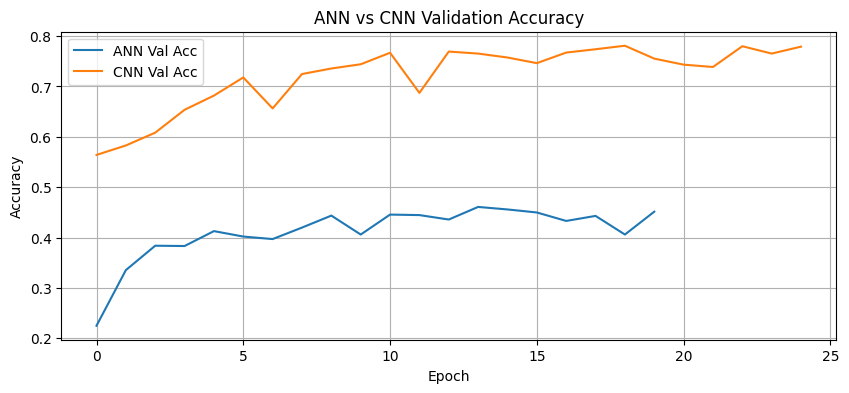

In [18]:
# Plot Comparison
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Key Learnings 

1. ANN accuracy is low (~42-46%) because it treats image as a flat vector and loses spatial relationship between pixels.
2. CNN accuracy is much higher (~72-78%) because Conv2D layers learn hierarchical features (edges → shapes → objects).
3. BatchNormalization and Dropout reduce overfitting.
4. Data Augmentation improves generalization by creating variations of images.
5. This assignment clearly shows why CNN is used in all real-world computer vision projects.

Resources Used: Official Celebal Technologies Week-4 notebook (Resources_Original_Notebook.ipynb)